In [1]:
from util import * 
import matplotlib.pyplot as plt 
from numpy import sin
import numpy as np

Corrcoef: 0.9621


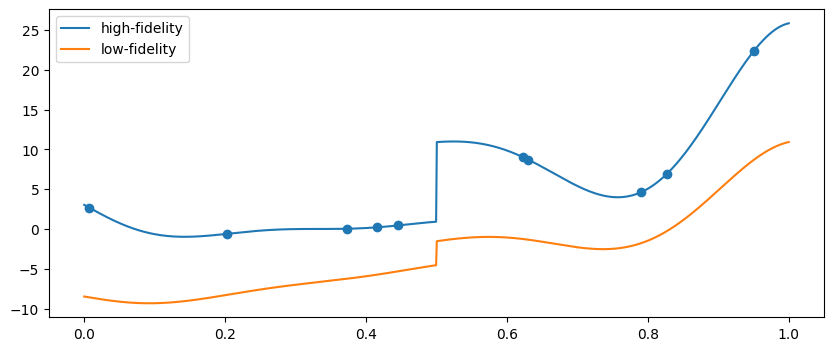

In [2]:
# LINEAR-B 

def y_lo(x):
    y = 0.5*(6*x-2)**2*sin(12*x-4)+10*(x-0.5)-5 
    y[x >= 0.5] += 3 
    return y 

def y_hi(x):
    y = 2*y_lo(x)-20*x+20
    y[x >= 0.5] += 4 
    return y 
    
funcs = [
    lambda x: y_hi(x),
    lambda x: y_lo(x)
]

# Assigning sample sizes
N_hi, N_lo, N_test = 10, 1000, 1000 
# Assigning computational budgets 
C_hi, C_lo = 5, 1 
X_hi = np.random.uniform(0,1.0, N_hi)
X_lo = np.random.uniform(0,1.0, N_lo)
X_test = np.linspace(0,1.0, N_test)

Y_hi = funcs[0](X_hi) #- np.mean(funcs[0](X_test))
Y_lo = funcs[1](X_lo) #- np.mean(funcs[1](X_test))

corr_coef = np.corrcoef(funcs[0](X_test), funcs[1](X_test))[0,1]

print("Corrcoef: %.4f" % corr_coef)

plt.figure(figsize=(10,4))
plt.plot(X_test, funcs[0](X_test), label = "high-fidelity")
plt.plot(X_test, funcs[1](X_test), label = "low-fidelity")
plt.scatter(X_hi, Y_hi)
plt.legend()

In [7]:
from sklearn.neural_network import MLPRegressor 

model = MLPRegressor(
    (100, 100, 100, 100), 
    activation='tanh',
    verbose=True, 
    max_iter=10000,
    solver='adam',
    alpha=1e-6,
    n_iter_no_change=5000,
    batch_size = N_lo,
    learning_rate = 'constant',
    learning_rate_init=1e-5,
    tol=1e-8,
    warm_start=True
)


In [9]:
model.learning_rate_init = 1e-3
model.beta_1, model.beta_2 = 0.95, 0.9999
model.fit(X_lo.reshape(-1,1), Y_lo)

Iteration 1, loss = 0.00782570
Iteration 2, loss = 0.37495533
Iteration 3, loss = 0.05713743
Iteration 4, loss = 0.08080178
Iteration 5, loss = 0.22548635
Iteration 6, loss = 0.17029807
Iteration 7, loss = 0.05066880
Iteration 8, loss = 0.01742860
Iteration 9, loss = 0.06625499
Iteration 10, loss = 0.12424795
Iteration 11, loss = 0.13614128
Iteration 12, loss = 0.09723389
Iteration 13, loss = 0.04084284
Iteration 14, loss = 0.00802764
Iteration 15, loss = 0.02623584
Iteration 16, loss = 0.06745566
Iteration 17, loss = 0.09212068
Iteration 18, loss = 0.08307622
Iteration 19, loss = 0.05060920
Iteration 20, loss = 0.01942642
Iteration 21, loss = 0.01174591
Iteration 22, loss = 0.02420919
Iteration 23, loss = 0.04621662
Iteration 24, loss = 0.06207595
Iteration 25, loss = 0.06269310
Iteration 26, loss = 0.04867838
Iteration 27, loss = 0.02858703
Iteration 28, loss = 0.01398746
Iteration 29, loss = 0.01272106
Iteration 30, loss = 0.02308589
Iteration 31, loss = 0.03758744
Iteration 32, los

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


MLPRegressor(activation='tanh', alpha=1e-06, batch_size=1000, beta_1=0.95,
             beta_2=0.9999, hidden_layer_sizes=(100, 100, 100, 100),
             max_iter=10000, n_iter_no_change=5000, tol=1e-08, verbose=True,
             warm_start=True)

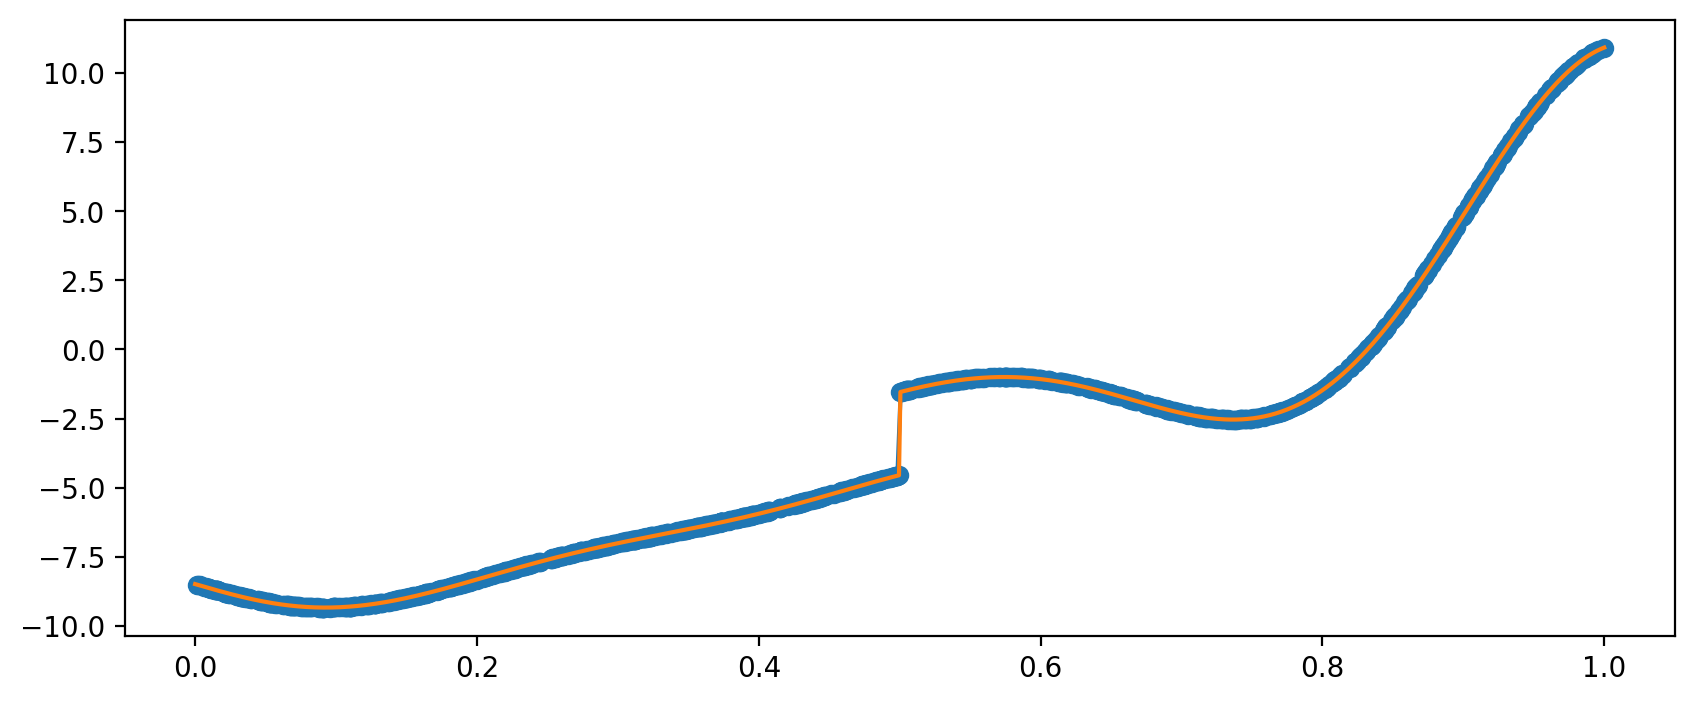

In [10]:
yhat = model.predict(X_test.reshape(-1,1))

plt.figure(figsize=(10,4), dpi = 200)
plt.plot(X_test, yhat)
plt.plot(X_test, funcs[1](X_test))
plt.scatter(X_lo, Y_lo)

In [11]:
Y_lo_hi = model.predict(X_hi.reshape(-1,1))
features = np.hstack((Y_lo_hi.reshape(-1,1), np.ones((N_hi, 1))))
rho, intercept = np.linalg.lstsq(features, Y_hi, rcond = 1e-15)[0]

discrepancy = Y_hi - rho * Y_lo_hi - intercept 

In [15]:
disc_model = MLPRegressor(
    (100, 100, 100, 100), 
    activation='tanh',
    verbose=True, 
    max_iter=10000,
    solver='adam',
    alpha=1e-6,
    n_iter_no_change=5000,
    batch_size = N_lo,
    learning_rate = 'constant',
    learning_rate_init=1e-5,
    tol=1e-8,
    warm_start=True
)

In [16]:
disc_model.learning_rate_init = 1e-3
disc_model.fit(X_hi.reshape(-1,1), discrepancy)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:609: UserWarning: Got `batch_size` less than 1 or larger than sample size. It is going to be clipped
  warnings.warn(


Iteration 1, loss = 2.26421451
Iteration 2, loss = 2.18824414
Iteration 3, loss = 2.11853034
Iteration 4, loss = 2.05702582
Iteration 5, loss = 2.00527207
Iteration 6, loss = 1.95871411
Iteration 7, loss = 1.92232962
Iteration 8, loss = 1.90066711
Iteration 9, loss = 1.89128516
Iteration 10, loss = 1.89594131
Iteration 11, loss = 1.90267052
Iteration 12, loss = 1.90398652
Iteration 13, loss = 1.89510132
Iteration 14, loss = 1.87590630
Iteration 15, loss = 1.85247305
Iteration 16, loss = 1.82838592
Iteration 17, loss = 1.80786846
Iteration 18, loss = 1.79261815
Iteration 19, loss = 1.78067194
Iteration 20, loss = 1.77116802
Iteration 21, loss = 1.76172843
Iteration 22, loss = 1.74918047
Iteration 23, loss = 1.73192752
Iteration 24, loss = 1.70855980
Iteration 25, loss = 1.67939333
Iteration 26, loss = 1.64582091
Iteration 27, loss = 1.60964865
Iteration 28, loss = 1.57356423
Iteration 29, loss = 1.53869336
Iteration 30, loss = 1.50387549
Iteration 31, loss = 1.46629697
Iteration 32, los

MLPRegressor(activation='tanh', alpha=1e-06, batch_size=1000,
             hidden_layer_sizes=(100, 100, 100, 100), max_iter=10000,
             n_iter_no_change=5000, tol=1e-08, verbose=True, warm_start=True)

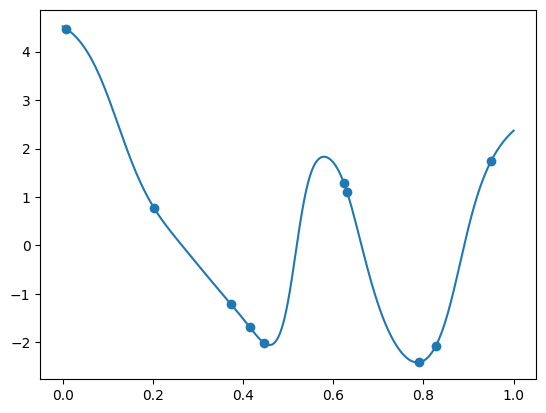

In [17]:
plt.scatter(X_hi, discrepancy)
plt.plot(X_test, disc_model.predict(X_test.reshape(-1,1)))

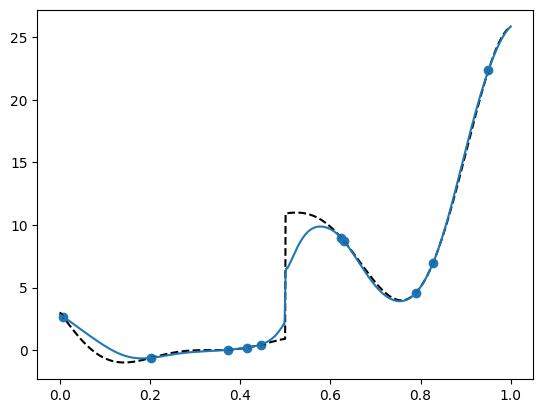

In [18]:
hf_preds = rho * model.predict(X_test.reshape(-1,1)) + intercept + disc_model.predict(X_test.reshape(-1,1))
plt.plot(X_test, funcs[0](X_test), color = 'black', linestyle = 'dashed', label = "Target")
plt.plot(X_test, hf_preds)
plt.scatter(X_hi, Y_hi)

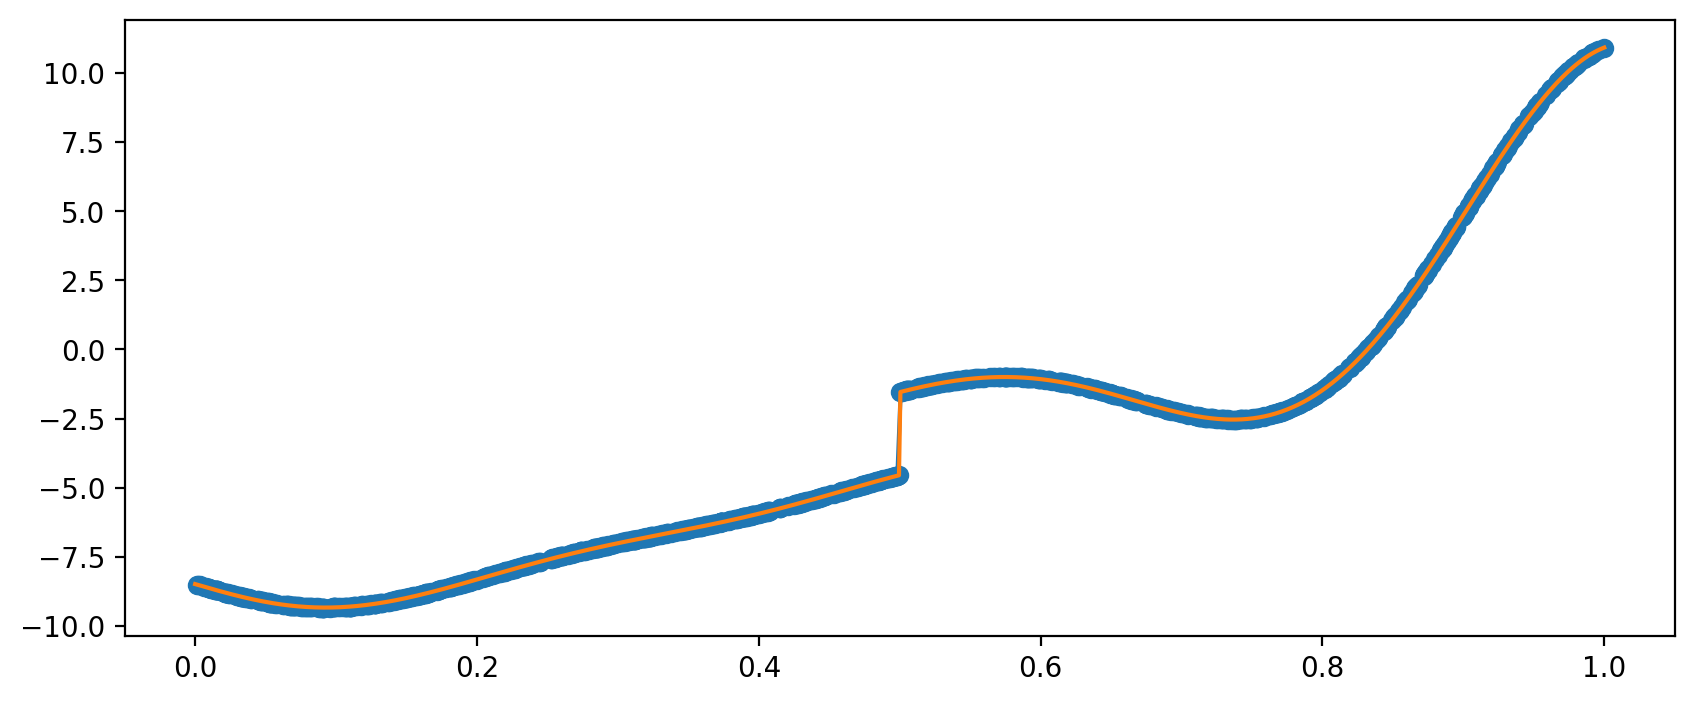

In [19]:
from copy import deepcopy 

hf_model = deepcopy(model)

yhat = hf_model.predict(X_test.reshape(-1,1))

plt.figure(figsize=(10,4), dpi = 200)
plt.plot(X_test, yhat)
plt.plot(X_test, funcs[1](X_test))
plt.scatter(X_lo, Y_lo)

In [250]:
hf_model.learning_rate_init = 1e-5
hf_model.max_iter = 10000
hf_model.n_iter_no_change = hf_model.max_iter
hf_model.alpha = 0.0
hf_model.tol = 1e-10
hf_model.batch_size = N_hi
hf_model.fit(X_hi.reshape(-1,1), (Y_hi - intercept) / rho)

Iteration 1, loss = 1.54834825
Iteration 2, loss = 1.53654011
Iteration 3, loss = 1.52497501
Iteration 4, loss = 1.51365432
Iteration 5, loss = 1.50257905
Iteration 6, loss = 1.49174993
Iteration 7, loss = 1.48116743
Iteration 8, loss = 1.47083181
Iteration 9, loss = 1.46074305
Iteration 10, loss = 1.45090087
Iteration 11, loss = 1.44130468
Iteration 12, loss = 1.43195358
Iteration 13, loss = 1.42284640
Iteration 14, loss = 1.41398162
Iteration 15, loss = 1.40535745
Iteration 16, loss = 1.39697177
Iteration 17, loss = 1.38882217
Iteration 18, loss = 1.38090591
Iteration 19, loss = 1.37321996
Iteration 20, loss = 1.36576094
Iteration 21, loss = 1.35852517
Iteration 22, loss = 1.35150865
Iteration 23, loss = 1.34470706
Iteration 24, loss = 1.33811577
Iteration 25, loss = 1.33172988
Iteration 26, loss = 1.32554417
Iteration 27, loss = 1.31955317
Iteration 28, loss = 1.31375116
Iteration 29, loss = 1.30813216
Iteration 30, loss = 1.30268999
Iteration 31, loss = 1.29741828
Iteration 32, los

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10000) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(activation='tanh', alpha=0.0, batch_size=10, beta_1=0.95,
             beta_2=0.9999, hidden_layer_sizes=(100, 100, 100, 100),
             learning_rate_init=1e-05, max_iter=10000, n_iter_no_change=10000,
             tol=1e-10, verbose=True, warm_start=True)

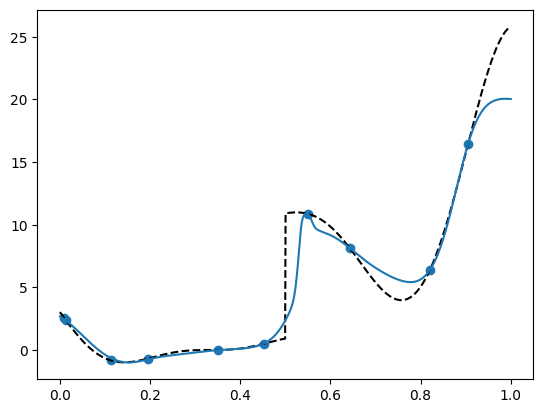

In [251]:
plt.plot(X_test, funcs[0](X_test), color = 'black', linestyle = 'dashed', label = "Target")
plt.plot(X_test, rho * hf_model.predict(X_test.reshape(-1,1)) + intercept)
plt.scatter(X_hi, Y_hi)

In [20]:
sf_model = MLPRegressor(
    (100, 100, 100, 100), 
    activation='tanh',
    verbose=False, 
    max_iter=10000,
    solver='adam',
    alpha=1e-6,
    n_iter_no_change=10000,
    learning_rate = 'constant',
    learning_rate_init=1e-2,
    tol=1e-8,
    warm_start=True
)

In [22]:
sf_model.fit(X_hi.reshape(-1,1), Y_hi)

MLPRegressor(activation='tanh', alpha=1e-06,
             hidden_layer_sizes=(100, 100, 100, 100), learning_rate_init=0.01,
             max_iter=10000, n_iter_no_change=10000, tol=1e-08,
             warm_start=True)

100%|██████████| 1000/1000 [00:22<00:00, 45.33it/s]


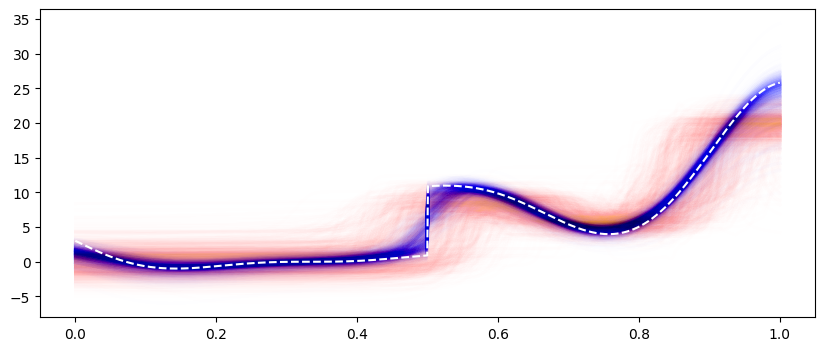

In [25]:
from sklearn.metrics import mean_squared_error as MSE
n_iter = 1000
N_hi = 10

sf_model.batch_size = N_hi

plt.figure(figsize=(10,4)) 

hf_mses = np.zeros(n_iter)
mf_mses = np.zeros(n_iter)

Y_hi_test = funcs[0](X_test)

for iter in tqdm(range(n_iter)):
    np.random.seed(iter)
    X_hi = np.random.uniform(0,1.0, N_hi)
    Y_hi = funcs[0](X_hi)


    sf_model.fit(X_hi.reshape(-1,1), Y_hi)

    yhat = sf_model.predict(X_test.reshape(-1,1))

    plt.plot(X_test, yhat, color = 'orange', alpha = 0.005, linewidth = 2.5)

    hf_mses[iter] = MSE(Y_hi_test, yhat)


for iter in tqdm(range(n_iter)):
    np.random.seed(iter)
    X_hi = np.random.uniform(0,1.0, N_hi)
    Y_hi = funcs[0](X_hi)

    
    # Making the discrepancy model 
    Y_lo_hi = model.predict(X_hi.reshape(-1,1))
    features = np.hstack((Y_lo_hi.reshape(-1,1), np.ones((N_hi, 1))))
    rho, intercept = np.linalg.lstsq(features, Y_hi, rcond = 1e-15)[0]

    disc_model.batch_size = N_hi

    discrepancy = Y_hi - rho * Y_lo_hi - intercept 

    # Training the discrepancy model 
    disc_model.verbose = False
    disc_model.fit(X_hi.reshape(-1,1), discrepancy)

    hf_preds = rho * model.predict(X_test.reshape(-1,1)) + intercept + disc_model.predict(X_test.reshape(-1,1))
    plt.plot(X_test, hf_preds, color = 'blue', alpha = 0.005, linewidth = 2.5)

    mf_mses[iter] = MSE(Y_hi_test, hf_preds)

plt.plot(X_test, funcs[0](X_test), color = 'white', linestyle = 'dashed')

(0.1, 40.0)

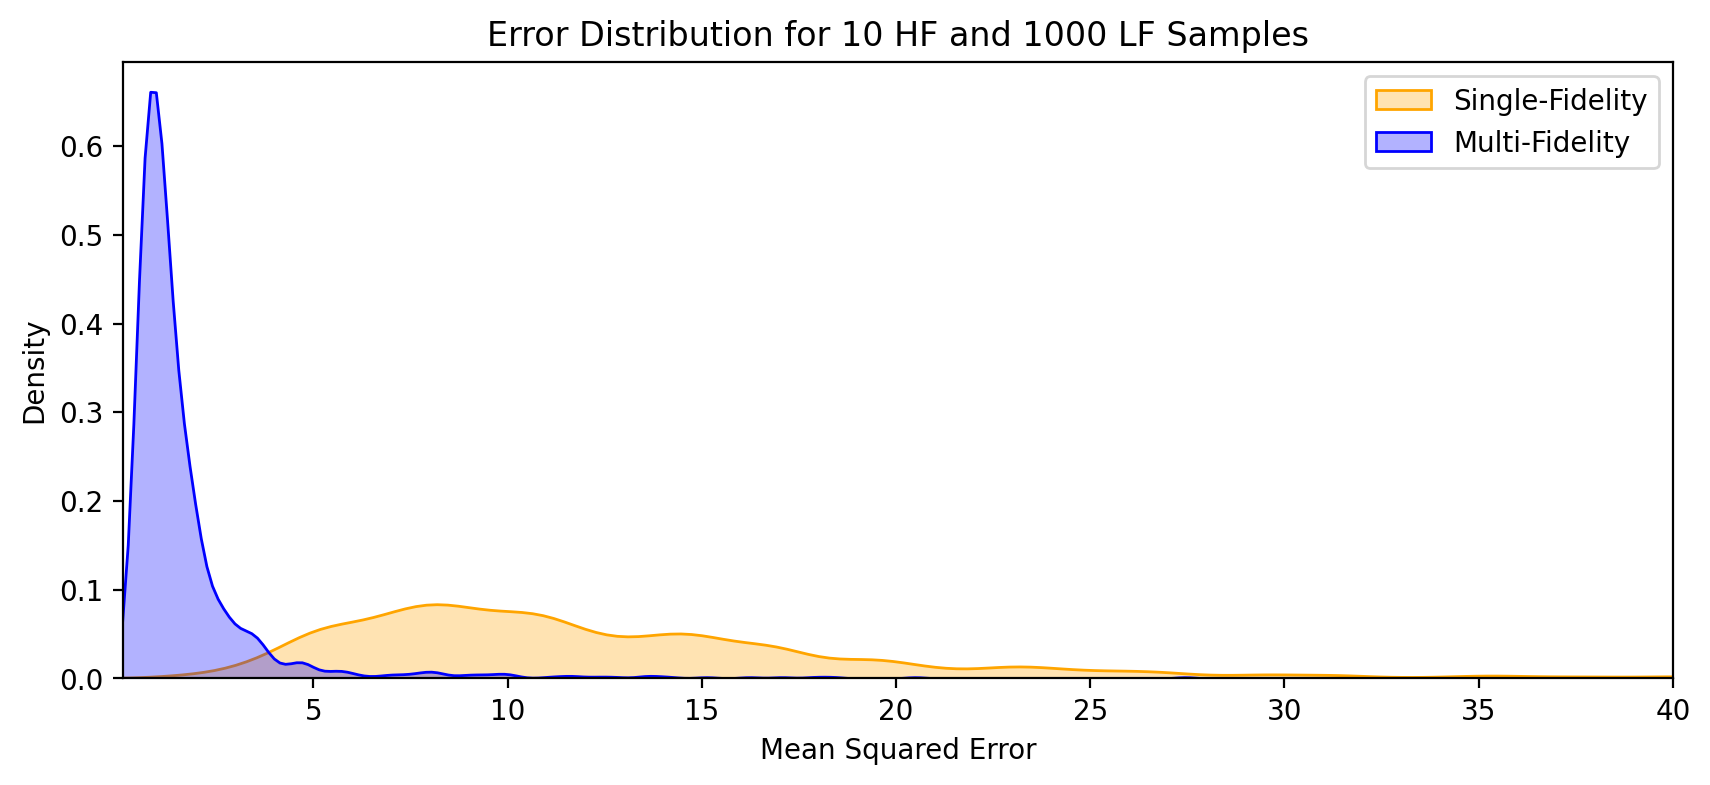

In [33]:
import seaborn as sns 

plt.figure(figsize=(10,4), dpi = 200)
sns.kdeplot(hf_mses, color = 'orange', fill=True, alpha = 0.3, label = "Single-Fidelity", bw_adjust = 0.5)
sns.kdeplot(mf_mses, color = 'blue', fill=True, alpha = 0.3, label = "Multi-Fidelity", bw_adjust = 0.5)
plt.legend()
plt.xlabel("Mean Squared Error")
plt.title("Error Distribution for 10 HF and 1000 LF Samples")
plt.xlim(1e-1,40)